# **Exploratory Data Analysis**

# **Setup Configuration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("transport_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Hour"] = pd.to_datetime(df["Departure Time"], format="%H:%M").dt.hour
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print(df.head())

  Route ID                          Route Name Bus Number  Bus Type  \
0      R08  South Terminal - Business District    BUS-309  Standard   
1      R05               West Gate - Tech Park    BUS-280  Standard   
2      R02          North Station - University    BUS-109        AC   
3      R04            East Suburb - Mall Plaza    BUS-392        AC   
4      R03                   Harbor - Downtown    BUS-367      Mini   

        Date Departure Time Arrival Time  Delay Duration  Passenger Count  \
0 2025-03-16          16:30        17:13               5               33   
1 2025-02-18          12:15        13:34               8               43   
2 2025-01-17          18:30        19:13               7               33   
3 2025-01-24          16:45        17:54              14               21   
4 2025-01-08          19:00        20:42              27               19   

   Ticket Revenue  Fuel Consumption Driver ID Weather Condition Day Type  \
0          2200.0              6.9

# **Statistical Summary**

In [2]:
print(df[["Delay Duration","Passenger Count","Ticket Revenue","Fuel Consumption"]].describe().round(1))
print("\nTotal trips:", len(df))
print(f"Total passengers: {df['Passenger Count'].sum():,}")
print(f"Total revenue: {df['Ticket Revenue'].sum():,.0f}")

       Delay Duration  Passenger Count  Ticket Revenue  Fuel Consumption
count          1300.0           1300.0          1300.0            1300.0
mean             11.1             32.3          2884.4               9.1
std               8.0              9.1          1190.7               4.2
min               0.0             10.0           600.0               0.0
25%               5.0             25.0          2040.0               7.2
50%              10.0             33.0          2733.5               9.7
75%              15.0             39.0          3600.0              12.1
max              63.0             50.0          6864.0              18.8

Total trips: 1300
Total passengers: 42,025
Total revenue: 3,749,771


# **Trend Analysis Monthly**

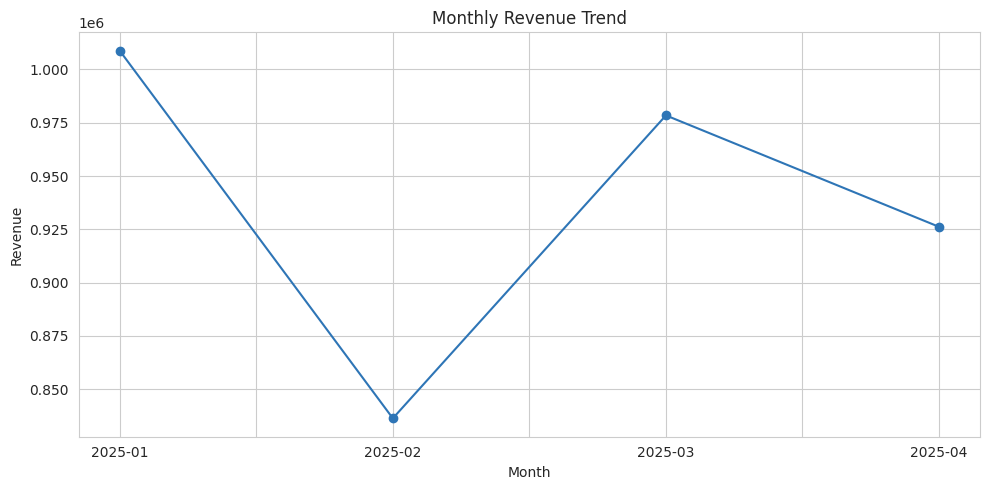

In [3]:
monthly = df.groupby("Month").agg(revenue=("Ticket Revenue","sum"), passengers=("Passenger Count","sum"))
monthly["revenue"].plot(marker="o", color="#2E75B6", title="Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# **Correlation Analysis**

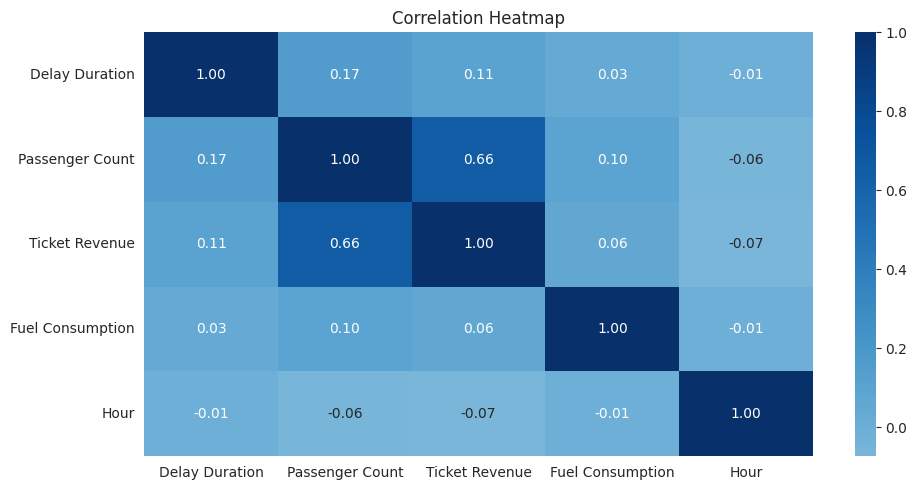

In [7]:
corr = df[["Delay Duration","Passenger Count","Ticket Revenue","Fuel Consumption","Hour"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# **Passenger Distribution**

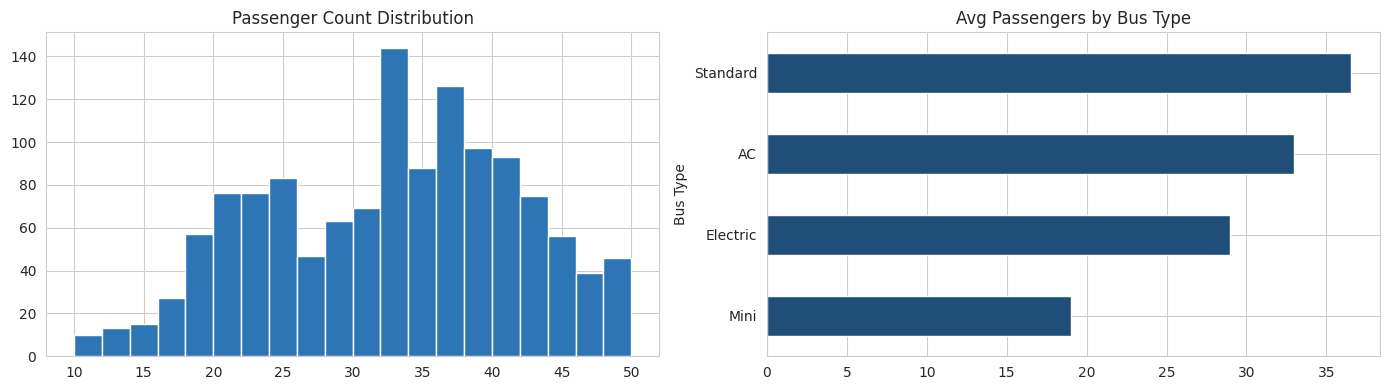

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
df["Passenger Count"].hist(bins=20, color="#2E75B6", ax=ax[0]); ax[0].set_title("Passenger Count Distribution")
df.groupby("Bus Type")["Passenger Count"].mean().sort_values().plot(kind="barh", color="#1F4E79", ax=ax[1])
ax[1].set_title("Avg Passengers by Bus Type")
plt.tight_layout()
plt.show()

# **Revenue Distribution**

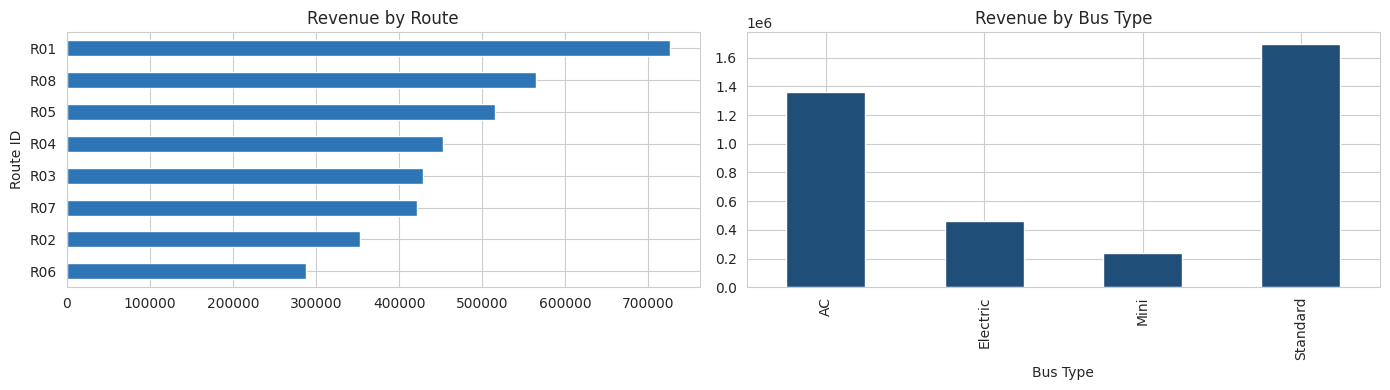

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
df.groupby("Route ID")["Ticket Revenue"].sum().sort_values().plot(kind="barh", color="#2E75B6", ax=ax[0])
ax[0].set_title("Revenue by Route")
df.groupby("Bus Type")["Ticket Revenue"].sum().plot(kind="bar", color="#1F4E79", ax=ax[1])
ax[1].set_title("Revenue by Bus Type")
plt.tight_layout()
plt.show()

# **Delay Analysis**

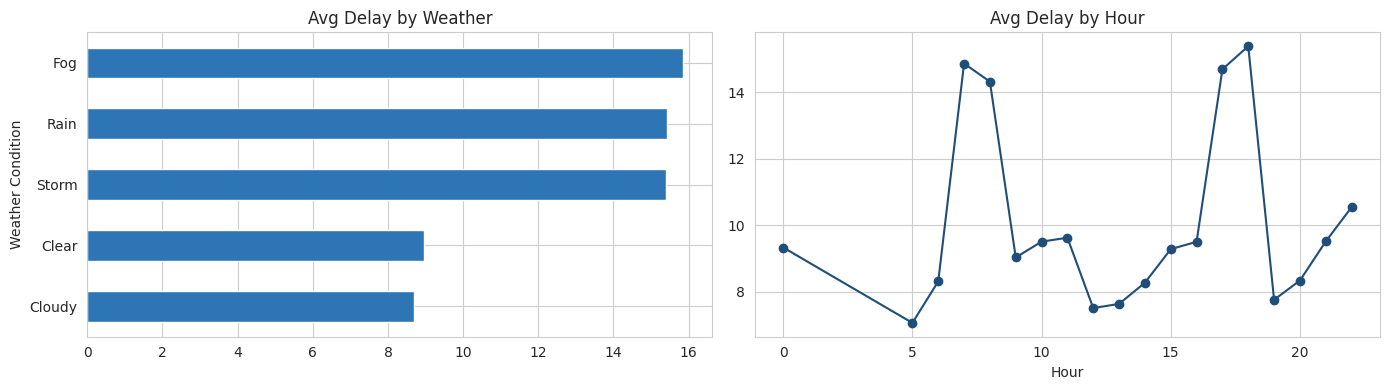

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
df.groupby("Weather Condition")["Delay Duration"].mean().sort_values().plot(kind="barh", color="#2E75B6", ax=ax[0])
ax[0].set_title("Avg Delay by Weather")
df.groupby("Hour")["Delay Duration"].mean().plot(marker="o", color="#1F4E79", ax=ax[1])
ax[1].set_title("Avg Delay by Hour")
plt.tight_layout()
plt.show()

# **Route Performance Analysis**

In [12]:
route_perf = df.groupby(["Route ID","Route Name"]).agg(
    trips=("Route ID","size"), passengers=("Passenger Count","sum"),
    revenue=("Ticket Revenue","sum"), avg_delay=("Delay Duration","mean")).round(1)
print(route_perf.sort_values("revenue", ascending=False))

                                             trips  passengers   revenue  \
Route ID Route Name                                                        
R01      City Center - Airport                 164        5411  725496.0   
R08      South Terminal - Business District    161        5189  565020.0   
R05      West Gate - Tech Park                 157        5169  514800.0   
R04      East Suburb - Mall Plaza              183        5780  453330.5   
R03      Harbor - Downtown                     157        4902  428544.0   
R07      Riverside - Stadium                   153        5090  422152.2   
R02      North Station - University            165        5328  352881.0   
R06      Old Town - Hospital                   160        5156  287547.5   

                                             avg_delay  
Route ID Route Name                                     
R01      City Center - Airport                    11.4  
R08      South Terminal - Business District       11.0  
R05      We

# **Visual Data Exploration**

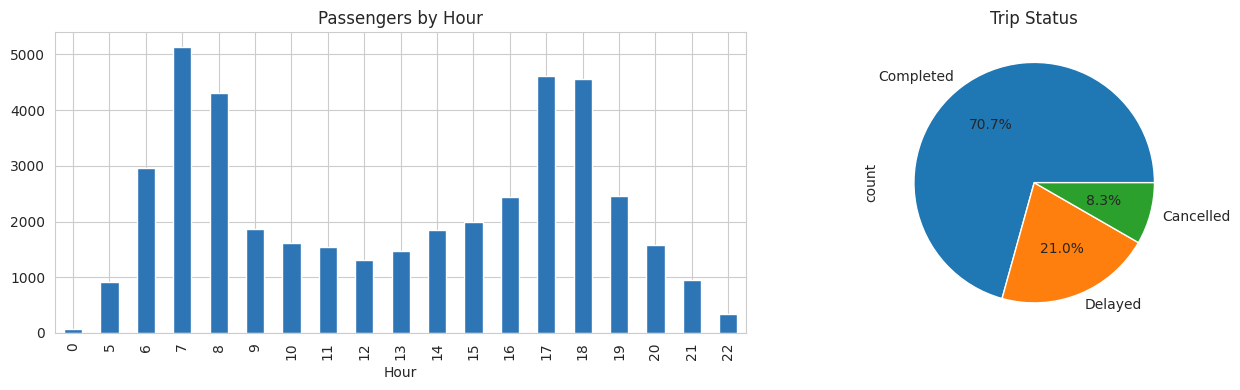

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
df.groupby("Hour")["Passenger Count"].sum().plot(kind="bar", color="#2E75B6", ax=ax[0])
ax[0].set_title("Passengers by Hour")
df["Trip Status"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Trip Status")
plt.tight_layout()
plt.show()

# **Observations And Insights**

- Weather is the primary delay lever. Delays are uniform across routes and hours but jump ~75% in fog/rain/storm. Route-specific fixes won't help; weather-contingent scheduling (buffer times on bad-weather days) will.

- Revenue and ridership are different stories. R01 earns most on high fares; R04 carries most passengers on low fares. A transit authority should treat these differently — R01 for revenue, R04 for capacity/crowding management.

- Peak hours are extreme and predictable. 7am and 5–6pm dominate ridership. Fleet allocation should concentrate there, and the lighter mid-day periods may be over-served.